# Baltimore Enterprise Zone Analysis: Empirical Strategy and Initial Results
**Urban Economics Final Paper | Spring 2026**

---

## Overview

This notebook implements the empirical analysis for the Baltimore City Enterprise Zone (EZ) 
paper. The central research question is whether EZ designations produce real (inflation-adjusted) 
property value appreciation above citywide trends. The analysis draws on a parcel-level panel 
dataset spanning 2002–2024 provided by the Maryland Department of Planning (MDP), spatially 
joined to 2012 and 2022 EZ and Focus Area boundary shapefiles provided by the Baltimore 
Development Corporation (BDC).

---

## Data

The working dataset is `full_panel`, loaded from `UrbanEconomics_EZ_analysis.gdb`. It contains
4,075,312 parcel-year observations across 38 columns. Key variables include:

- **Outcome variables**: `REAL_NFMTTLVL`, `LOG_REAL_NFMTTLVL` — real total assessed value 
  (land + improvements) deflated to 2024 dollars using the Baltimore-Columbia-Towson MSA CPI; 
  log transformation is the primary outcome for the regression
- **Treatment indicators**: `IN_EZ_2012`, `IN_EZ_2022`, `IN_FOCUS_EZ_2012`, `IN_FOCUS_EZ_2022` 
  — binary parcel-level designation flags derived from spatial join to BDC boundary shapefiles
- **Treatment group**: `TREATMENT_GROUP` — three-way classification: `not_treated`, `treated` 
  (in EZ), `extra_treated` (in Focus Area EZ)
- **Structural controls**: `SQFTSTRC` (structure square footage), `YEARBLT` (year built), 
  `ZONING` / `DESCLU` (land use classification), `IS_COMMERCIAL` (binary commercial use flag)
- **Panel identifiers**: `ACCTID` (parcel ID), `YEAR`

**Panel gaps**: The panel is unbalanced. The following years are absent from the MDP extract: 
2014, 2016, 2018, 2019, 2020. This is consequential for the 2012 wave analysis.

**2002 boundary data**: The original 2002 EZ boundary maps are unrecoverable. The pre-2012 
window is therefore used for parallel trends validation only, not as a clean untreated baseline 
(an active but unmapped EZ program was operating throughout 2002–2011).

---

## Analytical Plan

### Step 1: Descriptive Statistics, Sample Construction, and EDA 

- Constructed wave-aware static treatment tags (`EZ_TAG`, `FA_TAG`) from spatial 
  join indicators; corrected 2,447 boundary digitization artifacts where parcels 
  fell inside FA polygons but outside the broader EZ boundary
- **Figure 1:** Parallel trends preview — mean log real assessed value by treatment 
  group and year; pre-2022 trends broadly parallel across groups
- **Figure 2:** KDE stability check and distributional EDA — sampling confirmed 
  stable at n=50k; treatment group separation present in both commercial and 
  residential parcels, sharpest among commercial

### Step 2: Formal Parallel Trends Test
- Regress `LOG_REAL_NFMTTLVL` on year × treatment group interactions in the 
  pre-2022 window; report interaction coefficients and joint F-test

### Step 3: Primary OLS Estimation (2022 Wave)
- Estimate `ln(V_jt) = α + β₁·EZ_jt + β₂·FA_jt + X_jt·γ + δ_t + ε_jt` on the 
  2021–2024 window; full sample then separately by `IS_COMMERCIAL`

---

Results from this notebook feed directly into the **Empirical Strategy and Data** and 
**Results and Interpretation** subsections of Section II and III of the paper.
For more data processing & parcel analysis systens architecture, please see the remainder of the project located on my github: https://github.com/norsini1515/baltimoreparcel
which this notebook references

In [1]:
import geopandas as gpd
from pathlib import Path
import numpy as np
from baltimoreparcel.gis.io import read_gis_file
from baltimoreparcel.directories import PROJECT_DIR
from baltimoreparcel.utils import Logger, error, info, success, warn

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

gdb_path = PROJECT_DIR / "UrbanEconomics_EZ_analysis.gdb"

In [2]:
info(f"Reading full parcel panel from {gdb_path} . . .")
full_parcel_panel = gdf = read_gis_file(gdb_path, layer="full_panel")
display(f"Full parcel panel shape: {full_parcel_panel.shape}")

[INFO] Reading full parcel panel from C:\Users\nicho\Documents\ArcGIS_Projects\BaltimoreParcelProject\UrbanEconomics_EZ_analysis.gdb . . .


'Full parcel panel shape: (4075312, 49)'

In [3]:
display(f"Columns:", full_parcel_panel.columns)
display(full_parcel_panel.head(3))

'Columns:'

Index(['ACCTID', 'GEOGCODE', 'ADDRESS', 'STRTNUM', 'STRTNAM', 'OWNNAME1',
       'ZONING', 'LU', 'DESCLU', 'ACRES', 'LANDAREA', 'YEARBLT', 'SQFTSTRC',
       'STRUGRAD', 'NFMLNDVL', 'NFMIMPVL', 'NFMTTLVL', 'YEAR', 'REAL_NFMLNDVL',
       'REAL_NFMIMPVL', 'REAL_NFMTTLVL', 'LOG_NFMLNDVL', 'LOG_NFMIMPVL',
       'LOG_NFMTTLVL', 'LOG_REAL_NFMLNDVL', 'LOG_REAL_NFMIMPVL',
       'LOG_REAL_NFMTTLVL', 'NEIGHBORHOOD', 'IN_EZ_2012', 'IN_EZ_2022',
       'IN_FOCUS_EZ_2012', 'IN_FOCUS_EZ_2022', 'EXTRA_TREATED', 'TREATED',
       'NOT_TREATED', 'TREATMENT_GROUP', 'IS_COMMERCIAL', 'IS_RESIDENTIAL',
       'IS_CONDO', 'IS_MULTIFAMILY', 'IS_MIXED_USE', 'IS_EXEMPT',
       'STRUGRAD_AT_LEAST_FAIR', 'STRUGRAD_AT_LEAST_AVERAGE',
       'STRUGRAD_AT_LEAST_ABOVE_AVERAGE', 'STRUGRAD_AT_LEAST_GOOD',
       'STRUGRAD_VACANT', 'YEAR_DATE', 'geometry'],
      dtype='object')

,ACCTID,GEOGCODE,ADDRESS,STRTNUM,STRTNAM,OWNNAME1,ZONING,LU,DESCLU,ACRES,...,IS_MULTIFAMILY,IS_MIXED_USE,IS_EXEMPT,STRUGRAD_AT_LEAST_FAIR,STRUGRAD_AT_LEAST_AVERAGE,STRUGRAD_AT_LEAST_ABOVE_AVERAGE,STRUGRAD_AT_LEAST_GOOD,STRUGRAD_VACANT,YEAR_DATE,geometry
0,0301011738 001,82,2101 E BALTIMORE ST,2101,BALTIMORE,"LIBRA ENTERPRISES, LLC",0R100,R,Residential,0.041,...,0,0,0,0,0,0,0,0,2002-01-01 00:00:00+00:00,POINT (1429154.95 592039.498)
1,0301011738 001,82,2101 E BALTIMORE ST,2101,BALTIMORE,"PUCKETT, LAWRENCE J.",0R100,R,Residential,0.041,...,0,0,0,1,1,1,0,0,2003-01-01 00:00:00+00:00,POINT (1429154.95 592039.498)
2,0301011738 001,82,2101 E BALTIMORE ST,2101,BALTIMORE,"PUCKETT, LAWRENCE J.",0R100,R,Residential,0.041,...,0,0,0,1,1,1,1,0,2004-01-01 00:00:00+00:00,POINT (1429154.95 592039.498)


In [4]:
# ── Spatial consistency correction ─────────────────────────────────────────
# FA is a sub-designation of EZ; parcels inside FA boundary must be inside EZ
# The ~116 never_EZ|FA_2022_only cases are boundary digitization artifacts

mask_2012 = (full_parcel_panel['IN_FOCUS_EZ_2012'] == 1) & (full_parcel_panel['IN_EZ_2012'] == 0)
mask_2022 = (full_parcel_panel['IN_FOCUS_EZ_2022'] == 1) & (full_parcel_panel['IN_EZ_2022'] == 0)

info(f"IN_EZ_2012 corrections: {mask_2012.sum()}")
info(f"IN_EZ_2022 corrections: {mask_2022.sum()}")

full_parcel_panel.loc[mask_2012, 'IN_EZ_2012'] = 1
full_parcel_panel.loc[mask_2022, 'IN_EZ_2022'] = 1

[INFO]

 IN_EZ_2012 corrections: 150
[INFO] IN_EZ_2022 corrections: 2297


In [5]:
# ────────────────────────────────────────────────────────────────────────────────
def assign_wave_tags(row):
    
    # EZ tier
    if row['IN_EZ_2012'] == 1 and row['IN_EZ_2022'] == 0:
        ez_tag = 'EZ_2012_only'
    elif row['IN_EZ_2012'] == 0 and row['IN_EZ_2022'] == 1:
        ez_tag = 'EZ_2022_only'
    elif row['IN_EZ_2012'] == 1 and row['IN_EZ_2022'] == 1:
        ez_tag = 'EZ_both'
    else:
        ez_tag = 'never_EZ'

    # FA tier
    if row['IN_FOCUS_EZ_2012'] == 1 and row['IN_FOCUS_EZ_2022'] == 0:
        fa_tag = 'FA_2012_only'
    elif row['IN_FOCUS_EZ_2012'] == 0 and row['IN_FOCUS_EZ_2022'] == 1:
        fa_tag = 'FA_2022_only'
    elif row['IN_FOCUS_EZ_2012'] == 1 and row['IN_FOCUS_EZ_2022'] == 1:
        fa_tag = 'FA_both'
    else:
        fa_tag = 'never_FA'

    return ez_tag, fa_tag
# ──────────────────────────────────────────────────────────────────────────────
full_parcel_panel[['EZ_TAG', 'FA_TAG']] = full_parcel_panel.apply(
    assign_wave_tags, axis=1, result_type='expand'
)

In [6]:
display_cols = ['ACCTID', 'IN_EZ_2012', 'IN_EZ_2022', 'IN_FOCUS_EZ_2012', 'IN_FOCUS_EZ_2022', 'EZ_TAG', 'FA_TAG']

# ez_panel - one row per parcel, not per parcel-year, as tags are time-invariant at the parcel level
ez_panel = full_parcel_panel.drop_duplicates(subset='ACCTID')  # one row per parcel, not per parcel-year
display(ez_panel[display_cols].sample(10))

tag_counts = ez_panel.groupby(['EZ_TAG', 'FA_TAG']).size().reset_index(name='parcel_count')

display(
    tag_counts.sort_values(by=['EZ_TAG', 'FA_TAG', 'parcel_count'], ascending=[True, True, False])
)

,ACCTID,IN_EZ_2012,IN_EZ_2022,IN_FOCUS_EZ_2012,IN_FOCUS_EZ_2022,EZ_TAG,FA_TAG
2829915,0326206158A031,0,0,0,0,never_EZ,never_FA
1268665,0314100337 043,1,0,1,0,EZ_2012_only,FA_2012_only
314728,0306161711 090,0,0,0,0,never_EZ,never_FA
3461124,0327214511D025,0,0,0,0,never_EZ,never_FA
92093,0301131841 029,0,0,0,0,never_EZ,never_FA
3772860,0327535136A032,0,0,0,0,never_EZ,never_FA
907272,0311120507 032,1,1,0,0,EZ_both,never_FA
1863522,0318130158 026,1,0,0,0,EZ_2012_only,never_FA
1769793,0316232352 008,0,0,0,0,never_EZ,never_FA
521422,0308151540 023,0,0,0,0,never_EZ,never_FA


,EZ_TAG,FA_TAG,parcel_count
0,EZ_2012_only,FA_2012_only,557
1,EZ_2012_only,never_FA,4438
2,EZ_2022_only,FA_2022_only,1955
3,EZ_2022_only,never_FA,3772
4,EZ_both,FA_2012_only,43
5,EZ_both,FA_2022_only,2755
6,EZ_both,FA_both,2609
7,EZ_both,never_FA,11655
8,never_EZ,never_FA,208065


In [7]:
# ── Aggregate ──────────────────────────────────────────────────────────────
agg_ez = (
    full_parcel_panel
    .groupby(['YEAR', 'EZ_TAG'])['LOG_REAL_NFMTTLVL']
    .agg(mean='mean',
         se=lambda x: x.std() / np.sqrt(x.count()))
    .reset_index()
)

agg_fa = (
    full_parcel_panel
    .groupby(['YEAR', 'FA_TAG'])['LOG_REAL_NFMTTLVL']
    .agg(mean='mean',
         se=lambda x: x.std() / np.sqrt(x.count()))
    .reset_index()
)

# ── Plot ───────────────────────────────────────────────────────────────────
ez_palette = {
    'never_EZ':      '#888888',
    'EZ_2012_only':  '#2196F3',
    'EZ_2022_only':  '#FF7043',
    'EZ_both':       '#1B5E20',
}

fa_palette = {
    'never_FA':      '#888888',
    'FA_2012_only':  '#2196F3',
    'FA_2022_only':  '#FF7043',
    'FA_both':       '#1B5E20',
}

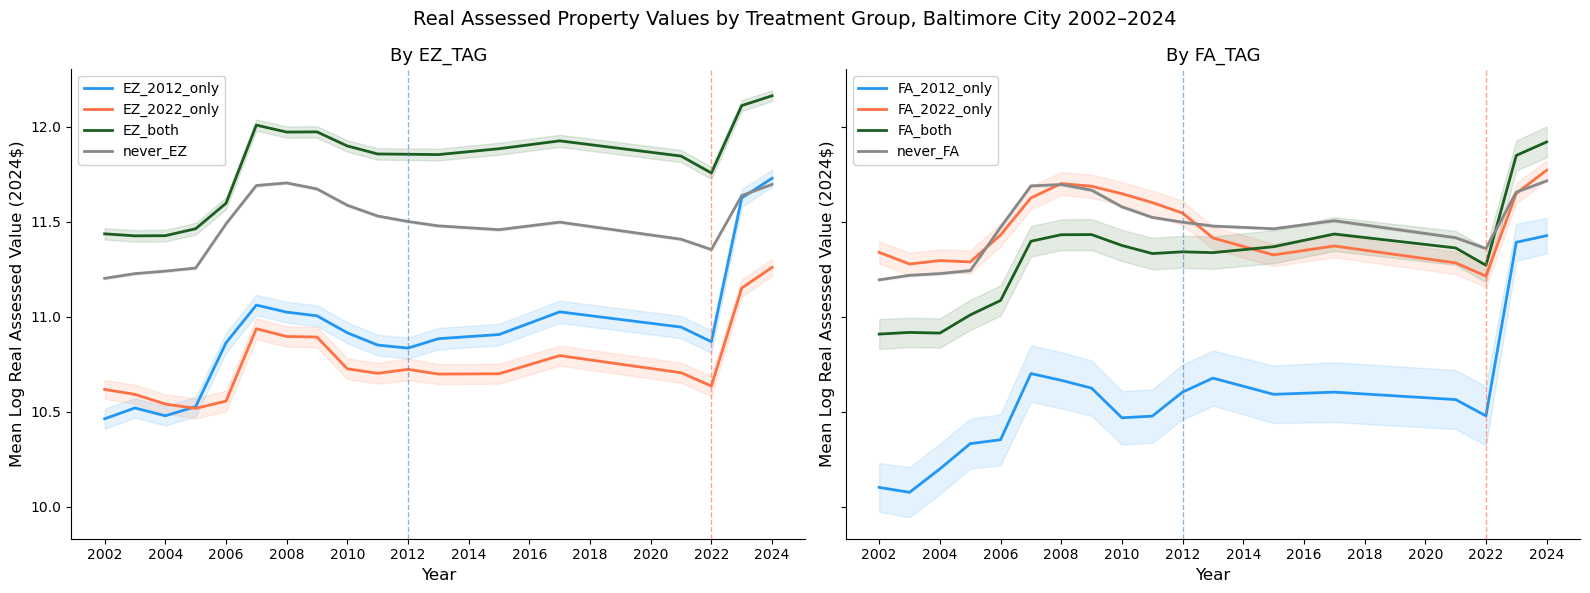

In [8]:
# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, agg, palette, tier in zip(
    axes,
    [agg_ez, agg_fa],
    [ez_palette, fa_palette],
    ['EZ_TAG', 'FA_TAG']
):
    for group, gdf in agg.groupby(tier):
        color = palette[group]
        ax.plot(gdf['YEAR'], gdf['mean'], label=group, color=color, linewidth=2)
        ax.fill_between(gdf['YEAR'], gdf['mean'] - (2*gdf['se']), gdf['mean'] + (2*gdf['se']), alpha=0.12, color=color)

    ax.axvline(2012, color='steelblue', linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(2022, color='tomato',    linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Mean Log Real Assessed Value (2024$)', fontsize=12)
    ax.set_title(f'By {tier}', fontsize=13)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.legend(fontsize=10, framealpha=0.9)
    sns.despine(ax=ax)

fig.suptitle('Real Assessed Property Values by Treatment Group, Baltimore City 2002–2024', fontsize=14)
plt.tight_layout()
plt.savefig('parallel_trends_by_tier.png', dpi=150)
plt.show()

## Figure 1: Parallel Trends Preview

The figure above plots mean log real assessed property value (2024 dollars) by treatment 
group across the full panel window, 2002–2024. Shaded bands represent ±2 standard errors 
of the group mean. Dashed vertical lines mark the 2012 and 2022 EZ redesignation years.

### What we are looking for
The parallel trends assumption underlying the 2022 treatment effect estimator requires 
that EZ-designated and non-designated parcels were trending similarly prior to the 2022 
redesignation. If the lines move roughly in parallel before 2022 and diverge after, that 
is consistent with the identifying assumption. Divergence *before* 2022 would be a red flag.

### What we see
**EZ panel (left):** The four groups occupy clearly different levels throughout the panel, 
reflecting the well-documented sorting of higher-value commercial and industrial parcels 
into persistent EZ designations (`EZ_both`). Crucially, the *slopes* of the lines are 
broadly similar across groups in the pre-2022 window, particularly between 2012 and 2021, 
which is the most relevant pre-period for the 2022 estimator. `EZ_2012_only` and 
`EZ_2022_only` track closely in levels and trend through the pre-2022 period, which is 
reassuring given that these groups represent parcels entering and exiting the program 
across waves.

**FA panel (right):** `FA_2012_only` carries a wide SE band throughout, reflecting its 
small group size (557 parcels), and should be interpreted cautiously. `FA_both` and 
`never_FA` track closely in trend if not in level through the pre-2022 window. `FA_2022_only` 
sits above `FA_both` in levels prior to 2022, which is worth noting: parcels newly 
elevated to Focus Area status in 2022 were already higher-valued on average than 
persistent FA parcels, suggesting the 2022 FA expansion targeted somewhat more 
commercially active corridors than the original FA designations.

### Caveats
The pre-2012 window should not be interpreted as a clean untreated baseline. An active 
EZ program was operating under the unrecoverable 2002 designation throughout 2002–2011, 
meaning some parcels in the `never_EZ` and `EZ_2022_only` groups may have received 
designation benefits during this period that are not captured in the treatment indicators.

The sharp post-2022 uptick visible across nearly all groups is likely attributable to 
a combination of genuine market appreciation, Maryland's triennial reassessment cycle 
catching up to the 2020-2022 real estate price surge, and the limitations of the 
CPI deflator in fully capturing localized property market dynamics. The year fixed 
effects in the regression absorb the citywide component of this jump but cannot fully 
separate these channels. This is discussed further in the limitations section.

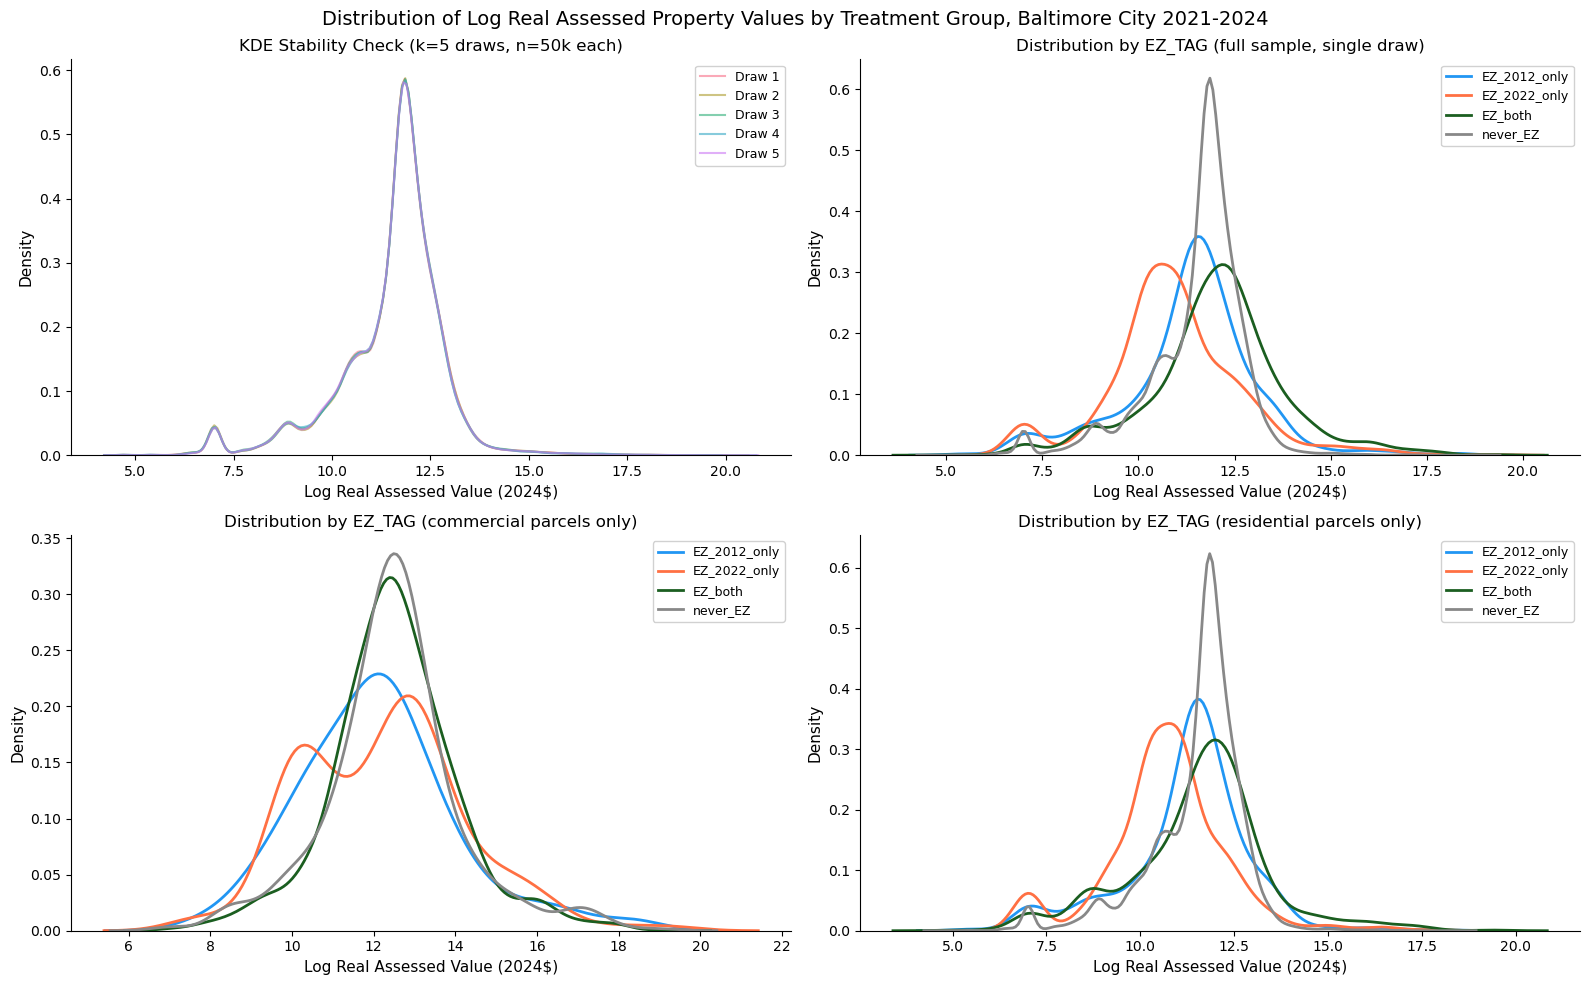

In [91]:
# ── 2x2 KDE Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

k = 5  # number of random draws for stability check
n=50000  # sample size for each draw
colors_k = sns.color_palette('husl', k)
ez_palette = {
    'EZ_2012_only': '#2196F3',
    'EZ_2022_only': '#FF7043',
    'EZ_both':      '#1B5E20',
    'never_EZ':     '#888888',
}

# filter valid values
plot_df = full_parcel_panel[
    full_parcel_panel['LOG_REAL_NFMTTLVL'].notna() &
    np.isfinite(full_parcel_panel['LOG_REAL_NFMTTLVL'])
].copy()

plot_df = plot_df[plot_df['YEAR']>=2021]  # focus on recent years for better visualization of current distribution

# single draw for panels 2, 3, 4
single_draw = plot_df.sample(n=n, random_state=42)

rng = np.random.default_rng(seed=42)  # reproducible random generator
# ── Top left: KDE stability check ─────────────────────────────────────────
for i in range(k):
    sample = plot_df.sample(n=n, random_state=rng.integers(1e6))
    sns.kdeplot(
        data=sample,
        x='LOG_REAL_NFMTTLVL',
        ax=axes[0, 0],
        color=colors_k[i],
        alpha=0.6,
        linewidth=1.5,
        label=f'Draw {i+1}'
    )
axes[0, 0].set_title('KDE Stability Check (k=5 draws, n=50k each)', fontsize=12)
axes[0, 0].legend(fontsize=9, framealpha=0.9)

# ── Top right: full sample by EZ_TAG ──────────────────────────────────────
for tag, grp in single_draw.groupby('EZ_TAG'):
    sns.kdeplot(
        data=grp,
        x='LOG_REAL_NFMTTLVL',
        ax=axes[0, 1],
        color=ez_palette[tag],
        linewidth=2,
        label=tag
    )
axes[0, 1].set_title('Distribution by EZ_TAG (full sample, single draw)', fontsize=12)
axes[0, 1].legend(fontsize=9, framealpha=0.9)

# ── Bottom left: commercial only ───────────────────────────────────────────
commercial = single_draw[single_draw['IS_COMMERCIAL'] == 1]
for tag, grp in commercial.groupby('EZ_TAG'):
    sns.kdeplot(
        data=grp,
        x='LOG_REAL_NFMTTLVL',
        ax=axes[1, 0],
        color=ez_palette[tag],
        linewidth=2,
        label=tag
    )
axes[1, 0].set_title('Distribution by EZ_TAG (commercial parcels only)', fontsize=12)
axes[1, 0].legend(fontsize=9, framealpha=0.9)

# ── Bottom right: residential only ─────────────────────────────────────────
residential = single_draw[single_draw['IS_COMMERCIAL'] == 0]
for tag, grp in residential.groupby('EZ_TAG'):
    sns.kdeplot(
        data=grp,
        x='LOG_REAL_NFMTTLVL',
        ax=axes[1, 1],
        color=ez_palette[tag],
        linewidth=2,
        label=tag
    )
axes[1, 1].set_title('Distribution by EZ_TAG (residential parcels only)', fontsize=12)
axes[1, 1].legend(fontsize=9, framealpha=0.9)

# ── Shared formatting ──────────────────────────────────────────────────────
for ax in axes.flat:
    ax.set_xlabel('Log Real Assessed Value (2024$)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    sns.despine(ax=ax)

fig.suptitle(
    'Distribution of Log Real Assessed Property Values by Treatment Group, Baltimore City 2021-2024',
    fontsize=14
)
plt.tight_layout()
plt.savefig('kde_2x2_2021.png', dpi=150)
plt.show()

## Figure 2: Distributional EDA — KDE Stability and Treatment Group Separation

The 2x2 grid above characterizes the distribution of log real assessed property values 
across the full panel, decomposed by treatment group and land use classification.

### Panel 1 (Top Left): KDE Stability Check
Five independent random draws of n=50,000 observations each produce nearly identical 
density estimates, with all five curves stacking indistinguishably on top of one another. 
This confirms that a 50,000 observation sample is fully representative of the underlying 
4,075,312 observation panel, and that subsequent single-draw distributional analyses are 
not sensitive to the particular sample drawn. All remaining panels use a single draw.

The full-sample distribution is notably multimodal, with distinct humps visible around 
log values of 5, 7.5, and 12. This structure is not noise — it reflects the mixing of 
fundamentally different parcel types in the full panel: low-value vacant and distressed 
parcels, small residential and commercial properties, and large commercial and industrial 
parcels all occupy very different ranges of the assessed value distribution. The bottom 
row confirms this is primarily a land use story.

### Panel 2 (Top Right): Full Sample by EZ_TAG
Grouping by EZ designation history reveals meaningful distributional separation across 
treatment groups. `never_EZ` parcels are concentrated narrowly around log value 12, 
reflecting the relative homogeneity of Baltimore's predominantly residential non-EZ 
parcels. EZ-designated groups exhibit flatter, wider distributions with substantially 
more left-tail mass, consistent with the program's targeting of distressed corridors 
where lower-valued parcels are concentrated. `EZ_both` parcels show the most pronounced 
rightward shift and heaviest right tail, reflecting the presence of large commercial and 
industrial parcels in corridors that have maintained continuous EZ designation across 
both waves. `EZ_2012_only` and `EZ_2022_only` occupy similar distributional ranges, 
suggesting that parcels entering and exiting the program across waves are drawn from 
comparable segments of the property value distribution.

### Panel 3 (Bottom Left): Commercial Parcels Only
Restricting to commercial parcels (`IS_COMMERCIAL == 1`) dramatically simplifies the 
distributional picture. The multimodal structure present in the full sample largely 
disappears, and all four groups converge toward a cleaner unimodal distribution. The 
treatment group separation persists and sharpens: `EZ_both` commercial parcels are 
shifted meaningfully rightward relative to `never_EZ` commercial parcels, with a 
pronounced right tail extending well above log value 15, consistent with large 
industrial and port-adjacent properties in continuously designated corridors. 
`EZ_2022_only` commercial parcels sit between `EZ_both` and `never_EZ`, suggesting 
newly designated commercial corridors are being drawn from a somewhat lower segment 
of the commercial value distribution than established EZ areas. This panel most 
directly reflects the primary theoretical mechanism: EZ incentives target commercial 
investment, and it is among commercial parcels that capitalization effects should be 
most visible.

### Panel 4 (Bottom Right): Residential Parcels Only
The residential panel reveals that the multimodal structure in the full sample is 
almost entirely a residential story. `never_EZ` residential parcels are extraordinarily 
concentrated around log value 12, a sharp spike consistent with Baltimore's highly 
homogeneous rowhouse stock assessed within a narrow value band. EZ-designated 
residential groups exhibit markedly greater distributional spread, with substantially 
more left-tail mass reflecting the concentration of distressed, low-value residential 
properties within designated boundaries. This distributional heterogeneity within 
EZ-designated residential parcels motivates including `IS_COMMERCIAL` as a control 
in the regression and running separate specifications by land use classification.

### Key Takeaways
- Sampling is stable and 50k draws are sufficient for reliable EDA
- Treatment group separation is present in both commercial and residential parcels 
  but operates through different mechanisms
- The full-sample multimodal distribution is a land use mixing artifact, not a 
  data quality problem
- `EZ_both` parcels are systematically higher-valued than other EZ groups, 
  reinforcing the need for year fixed effects and structural controls to isolate 
  the treatment effect from pre-existing level differences
- Running the regression separately by `IS_COMMERCIAL` is warranted given the 
  clearly different distributional structures across land use types

## Step 2:

In [10]:
# ── Step 2: Formal Parallel Trends Test ────────────────────────────────────
import linearmodels as lm
from linearmodels.panel import PanelOLS
import scipy.stats as stats
import numpy as np

# ── Sample construction ─────────────────────────────────────────────────────
PRE_PERIOD_PRIMARY   = list(range(2012, 2022))  # 2012-2021
PRE_PERIOD_SECONDARY = list(range(2002, 2022))  # 2002–2021

# Omit never_EZ (baseline group) and 2021 (baseline year)
BASELINE_GROUP = 'never_EZ'
BASELINE_YEAR  = 2021


def run_parallel_trends_test(df: pd.DataFrame, years: list, label: str) -> dict:
    pre = (
        df[df['YEAR'].isin(years)].copy()
          .set_index(['ACCTID', 'YEAR'])
    )

    ez_groups    = [g for g in df['EZ_TAG'].unique() if g != BASELINE_GROUP]
    available_years = pre.index.get_level_values('YEAR').unique()
    year_dummies = [y for y in years if y != BASELINE_YEAR and y in available_years]
    print(f"Years included in {label} test: {year_dummies}")

    for group in ez_groups:
        for year in year_dummies:
            col = f'INT_{group}_{year}'
            pre[col] = (
                (pre['EZ_TAG'] == group).astype(int) *
                (pre.index.get_level_values('YEAR') == year).astype(int)
            )

    interaction_cols = [f'INT_{g}_{y}' for g in ez_groups for y in year_dummies]

    # Drop any zero-variance columns before fitting — these cause rank failure
    exog = pre[interaction_cols]
    nonzero_cols = exog.columns[exog.std() > 0].tolist()
    dropped = set(interaction_cols) - set(nonzero_cols)
    if dropped:
        warn(f"[{label}] Dropping {len(dropped)} zero-variance interaction columns: {dropped}")

    mod = PanelOLS(
        dependent=pre['LOG_REAL_NFMTTLVL'],
        exog=exog[nonzero_cols],
        entity_effects=True,
        drop_absorbed=True,
    )
    res = mod.fit(cov_type='clustered', cluster_entity=True)

    f_stat, p_val = res.f_statistic.stat, res.f_statistic.pval
    info(f"\n[{label}] Parallel trends F-test: F={f_stat:.3f}, p={p_val:.4f}")
    info(f"[{label}] N obs: {res.nobs:,} | N entities: {res.entity_info.total:,}")

    return {'label': label, 'result': res, 'interaction_cols': nonzero_cols}


# ── Step 2b: Wald Test on Interaction Terms Only ───────────────────────────

def run_wald_test(res_dict: dict) -> None:
    res   = res_dict['result']
    label = res_dict['label']
    cols  = res_dict['interaction_cols']

    # Build restriction matrix: one row per interaction term, identity block
    # This tests H0: all interaction coefficients = 0 jointly
    all_params = list(res.params.index)
    R = np.zeros((len(cols), len(all_params)))
    for i, col in enumerate(cols):
        j = all_params.index(col)
        R[i, j] = 1.0

    wald = res.wald_test(R)
    info(
        f"[{label}] Wald test on interaction terms only: "
        f"F={wald.stat:.3f}, df=({len(cols)}, {res.df_resid:.0f}), p={wald.pval:.4f}"
    )
    print("-" * 80)
    print("\n")





results = {}
results['primary']   = run_parallel_trends_test(full_parcel_panel, PRE_PERIOD_PRIMARY,   '2012–2021')
run_wald_test(results['primary'])

results['secondary'] = run_parallel_trends_test(full_parcel_panel, PRE_PERIOD_SECONDARY, '2002–2021')
run_wald_test(results['secondary'])

Years included in 2012–2021 test: [2012, 2013, 2015, 2017]
[INFO] 
[2012–2021] Parallel trends F-test: F=106.431, p=0.0000
[INFO] [2012–2021] N obs: 1,146,543 | N entities: 231,595.0
[INFO] [2012–2021] Wald test on interaction terms only: F=7347.128, df=(12, 914936), p=0.0000
--------------------------------------------------------------------------------


Years included in 2002–2021 test: [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2015, 2017]
[INFO] 
[2002–2021] Parallel trends F-test: F=971.475, p=0.0000
[INFO] [2002–2021] N obs: 3,414,687 | N entities: 235,741.0
[INFO] [2002–2021] Wald test on interaction terms only: F=14819.574, df=(42, 3178904), p=0.0000
--------------------------------------------------------------------------------




In [11]:
display(results['primary'])
display(results['secondary'])

{'label': '2012–2021',
 'result':                           PanelOLS Estimation Summary                           
 Dep. Variable:      LOG_REAL_NFMTTLVL   R-squared:                        0.0014
 Estimator:                   PanelOLS   R-squared (Between):              0.0008
 No. Observations:             1146543   R-squared (Within):               0.0014
 Date:                Thu, May 07 2026   R-squared (Overall):              0.0007
 Time:                        11:21:40   Log-likelihood                -1.753e+05
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      106.43
 Entities:                      231595   P-value                           0.0000
 Avg Obs:                       4.9506   Distribution:               F(12,914936)
 Min Obs:                       1.0000                                           
 Max Obs:                       5.0000   F-statistic (robust):   

{'label': '2002–2021',
 'result':                           PanelOLS Estimation Summary                           
 Dep. Variable:      LOG_REAL_NFMTTLVL   R-squared:                        0.0127
 Estimator:                   PanelOLS   R-squared (Between):             -0.0004
 No. Observations:             3414687   R-squared (Within):               0.0127
 Date:                Thu, May 07 2026   R-squared (Overall):             -0.0002
 Time:                        11:22:12   Log-likelihood                -2.032e+06
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      971.47
 Entities:                      235741   P-value                           0.0000
 Avg Obs:                       14.485   Distribution:              F(42,3178904)
 Min Obs:                       1.0000                                           
 Max Obs:                       15.000   F-statistic (robust):   

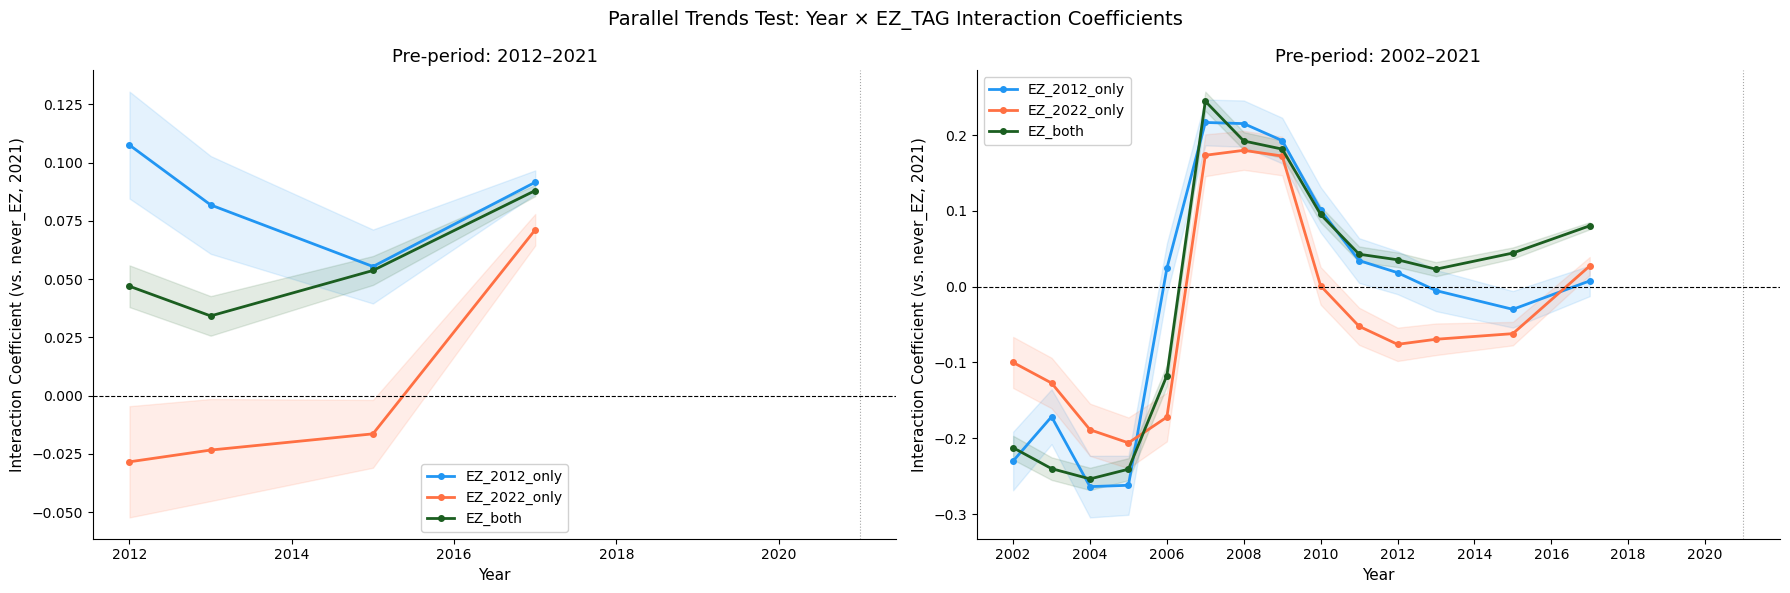

In [13]:
# ── Coefficient plot: interaction terms by window ──────────────────────────
ez_palette = {
    'EZ_2012_only': '#2196F3',
    'EZ_2022_only': '#FF7043',
    'EZ_both':      '#1B5E20',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, (key, res_dict) in zip(axes, results.items()):
    res = res_dict['result']
    params = res.params
    ci     = res.conf_int()

    for group, color in ez_palette.items():
        cols  = [c for c in res_dict['interaction_cols'] if group in c]
        years = [int(c.split('_')[-1]) for c in cols]
        coefs = [params[c] for c in cols]
        lo    = [ci.loc[c, 'lower'] for c in cols]
        hi    = [ci.loc[c, 'upper'] for c in cols]

        ax.plot(years, coefs, color=color, linewidth=2, label=group, marker='o', markersize=4)
        ax.fill_between(years, lo, hi, alpha=0.12, color=color)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(BASELINE_YEAR, color='grey', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_title(f'Pre-period: {res_dict["label"]}', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Interaction Coefficient (vs. never_EZ, 2021)', fontsize=11)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.legend(fontsize=10, framealpha=0.9)
    sns.despine(ax=ax)

fig.suptitle('Parallel Trends Test: Year × EZ_TAG Interaction Coefficients', fontsize=14)
plt.tight_layout()
plt.savefig('parallel_trends_formal.png', dpi=150)
plt.show()

## Step 2: Formal Parallel Trends Test — Results

### Setup
The parallel trends assumption underlying the 2022 DiD estimator requires that 
EZ-designated and non-designated parcels trended similarly in assessed values prior 
to the 2022 redesignation. To test this formally, we regress `LOG_REAL_NFMTTLVL` on 
a full set of year x `EZ_TAG` interaction terms in the pre-2022 window, with parcel 
fixed effects absorbed via `PanelOLS`. The omitted baseline group is `never_EZ` and 
the omitted baseline year is 2021 (the final pre-treatment year), so each interaction 
coefficient captures how the gap between a treatment group and `never_EZ` in year *t* 
differed  in year *t* from that same gap in 2021. 
Under parallel trends, all interaction coefficients should be statistically indistinguishable from zero. 
Standard errors are clustered at the parcel level. 
Two windows are estimated: a primary window (2012–2021) and a secondary window (2002-2021).

Note: due to gaps in the MDP extract, only four years are available in the primary 
window (2012, 2013, 2015, 2017), which limits the resolution of the pre-trend test 
for the 2022 wave.

### Wald Test Results

| Window | Interaction terms | F-statistic | df | p-value |
|--------|-------------------|-------------|----|---------|
| 2012-2021 (primary) | 12 | 7,347.1 | (12, 914,936) | 0.0000 |
| 2002-2021 (secondary) | 42 | 14,819.6 | (42, 3,178,904) | 0.0000 |

Both joint Wald tests formally reject the null of parallel trends. However, this 
result should be interpreted in light of the sample size. With over 1.1 million 
observations in the primary window, the test has sufficient power to reject even 
trivially small deviations from zero. The economically relevant question is not 
whether the interaction coefficients are statistically distinguishable from zero, 
but whether they reflect a systematic pre-treatment trend that would bias the 2022 
treatment effect estimate.

### Coefficient Plot (Figure 3)

Inspection of the interaction coefficients in the primary window (left panel) does 
not reveal a systematic pre-treatment trend. Coefficients for `EZ_both` and 
`EZ_2012_only` are positive throughout (ranging 0.03-0.11 log points) but stable 
and non-drifting across the available pre-period years. `EZ_2022_only` coefficients 
are negative and small in magnitude (approximately -0.02 to -0.03 log points), also 
without a discernible trend. Crucially, none of the three groups show a monotonic 
divergence from the `never_EZ` baseline going into 2021, which would be the pattern 
most threatening to the identifying assumption.

The secondary window (right panel) shows large swings across all groups during 
2004-2008, coinciding with the housing boom and bust cycle. This is attributable to 
the unmapped 2002 EZ designation operating throughout 2002-2011: parcels classified 
as `never_EZ` and `EZ_2022_only` in our data may have received designation benefits 
during this period, contaminating the `never_EZ` baseline and producing spurious 
divergence. The 2002-2021 window is therefore not a valid parallel trends test and 
is presented only to illustrate the boundary data limitation.

### Assessment

The parallel trends assumption is not cleanly satisfied in a formal statistical sense, 
but the primary window coefficient plot does not reveal the kind of systematic 
pre-treatment divergence that would invalidate the 2022 DiD estimator. The Wald test 
rejection is driven by the precision of estimation at N=1.1M rather than economically 
meaningful differential trends. We proceed with the 2022 wave OLS estimation with 
this limitation noted, and include year fixed effects and structural controls to absorb 
remaining sources of confounding.

## Step 3

In [19]:
full_parcel_panel["STRUGRAD"] = pd.to_numeric(full_parcel_panel["STRUGRAD"], errors='coerce').astype('Int64')
full_parcel_panel["STRUGRAD"].value_counts()

STRUGRAD
3    2105343
4     331010
0     295752
5     213335
6      85051
7       6591
2       4001
8       3697
1       1645
9        434
Name: count, dtype: Int64

In [15]:
full_parcel_panel["LU"].value_counts()

LU
R     3407824
U      196167
E      173164
C      151458
EC      63993
M       36992
I       33023
CC      12039
RC        407
CR        240
TH          2
A           1
Name: count, dtype: int64

In [20]:
full_parcel_panel["STRUGRAD"] = pd.to_numeric(full_parcel_panel["STRUGRAD"], errors='coerce')
display(full_parcel_panel.columns)

Index(['ACCTID', 'GEOGCODE', 'ADDRESS', 'STRTNUM', 'STRTNAM', 'OWNNAME1',
       'ZONING', 'LU', 'DESCLU', 'ACRES', 'LANDAREA', 'YEARBLT', 'SQFTSTRC',
       'STRUGRAD', 'NFMLNDVL', 'NFMIMPVL', 'NFMTTLVL', 'YEAR', 'REAL_NFMLNDVL',
       'REAL_NFMIMPVL', 'REAL_NFMTTLVL', 'LOG_NFMLNDVL', 'LOG_NFMIMPVL',
       'LOG_NFMTTLVL', 'LOG_REAL_NFMLNDVL', 'LOG_REAL_NFMIMPVL',
       'LOG_REAL_NFMTTLVL', 'NEIGHBORHOOD', 'IN_EZ_2012', 'IN_EZ_2022',
       'IN_FOCUS_EZ_2012', 'IN_FOCUS_EZ_2022', 'EXTRA_TREATED', 'TREATED',
       'NOT_TREATED', 'TREATMENT_GROUP', 'IS_COMMERCIAL', 'IS_RESIDENTIAL',
       'IS_CONDO', 'IS_MULTIFAMILY', 'IS_MIXED_USE', 'IS_EXEMPT',
       'STRUGRAD_AT_LEAST_FAIR', 'STRUGRAD_AT_LEAST_AVERAGE',
       'STRUGRAD_AT_LEAST_ABOVE_AVERAGE', 'STRUGRAD_AT_LEAST_GOOD',
       'STRUGRAD_VACANT', 'YEAR_DATE', 'geometry', 'EZ_TAG', 'FA_TAG'],
      dtype='object')

In [22]:
sample_2021_2024 = full_parcel_panel[
    (full_parcel_panel['YEAR'] >= 2021)
].copy()
display(f"Sample 2021-2024 shape: {sample_2021_2024.shape}")

'Sample 2021-2024 shape: (890359, 51)'

In [23]:
sample_2021_2024['IS_EXEMPT'].value_counts()

IS_EXEMPT
0    847749
1     42610
Name: count, dtype: int64

In [27]:
x = sample_2021_2024.pivot_table(index='ACCTID', columns='YEAR', values='STRUGRAD', aggfunc='mean')
x['mean_strugrad'] = x.mean(axis=1)
# display(x['mean_strugrad'].value_counts())
display(sample_2021_2024['FA_TAG'].value_counts())

FA_TAG
never_FA        864260
FA_2022_only     16060
FA_both           8107
FA_2012_only      1932
Name: count, dtype: int64

In [81]:
# ── Step 3: Primary OLS ─────────────────────────────────────────────────────
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# ── Sample ──────────────────────────────────────────────────────────────────
BASELINE_EZ = 'never_EZ'
BASELINE_FA = 'never_FA'
NUMERIC_CONTROLS = [
    'STRUGRAD', 'LANDAREA', 'YEARBLT', 'SQFTSTRC',
    'IS_COMMERCIAL', 'IS_MULTIFAMILY', 'IS_CONDO', 'IS_MIXED_USE',
    'STRUGRAD_AT_LEAST_AVERAGE', 'STRUGRAD_AT_LEAST_GOOD', 'STRUGRAD_VACANT',
]

ez_groups = [g for g in sample_2021_2024['EZ_TAG'].unique() if g != BASELINE_EZ]
fa_groups = [g for g in sample_2021_2024['FA_TAG'].unique() if g != BASELINE_FA]

def build_model_df(df: pd.DataFrame) -> pd.DataFrame:
    #drop is exempt parcels
    # mod_df = (
    #     df[~df['IS_EXEMPT'].astype(bool)]
    #       .copy()
    #       .set_index(['ACCTID', 'YEAR'])
    # )
    mod_df = df.copy().set_index(['ACCTID', 'YEAR'])
    year = mod_df.index.get_level_values('YEAR')

    # Time-varying EZ treatment: 1 if parcel is in an ACTIVE EZ in that year
    # 2012 zone was active pre-2022, 2022 zone active from 2022 onward
    mod_df['IN_EZ_ACTIVE'] = (
        ((mod_df['IN_EZ_2012'] == 1) & (year < 2022)) |
        ((mod_df['IN_EZ_2022'] == 1) & (year >= 2022))
    ).astype(int)

    # Time-varying FA treatment: same logic
    mod_df['IN_FA_ACTIVE'] = (
        ((mod_df['IN_FOCUS_EZ_2012'] == 1) & (year < 2022)) |
        ((mod_df['IN_FOCUS_EZ_2022'] == 1) & (year >= 2022))
    ).astype(int)

    # EZ_TAG group dummies still useful for heterogeneity — keep but don't use as primary treatment
    for g in ez_groups:
        mod_df[f'EZ_{g}'] = (mod_df['EZ_TAG'] == g).astype(int)

    # FA_TAG group dummies
    for g in fa_groups:
        mod_df[f'FA_{g}'] = (mod_df['FA_TAG'] == g).astype(int)

    # Year dummies (omit 2021 as baseline)
    for y in [2022, 2023, 2024]:
        mod_df[f'YEAR_{y}'] = (year == y).astype(int)

    #  # Neighborhood dummies (omit most common as baseline)
    # baseline_neighborhood = mod_df['NEIGHBORHOOD'].value_counts().idxmax()
    # print(f"Baseline neighborhood for dummies: {baseline_neighborhood}")
    # neighborhoods = [n for n in mod_df['NEIGHBORHOOD'].unique() if n != baseline_neighborhood]
    # for n in neighborhoods:
    #     mod_df[f'NBD_{n}'] = (mod_df['NEIGHBORHOOD'] == n).astype(int)
    # info(f"Added {len(neighborhoods)} neighborhood dummies (baseline: {baseline_neighborhood})")

    # Numeric Controls
    mod_df['STRUGRAD'] = mod_df['STRUGRAD'].astype(float)
    for col in NUMERIC_CONTROLS:
        mod_df[col] = pd.to_numeric(mod_df[col], errors='coerce')

    return mod_df


mod_df = build_model_df(sample_2021_2024)
display(mod_df.head(5))

GEOGCODE              ADDRESS STRTNUM    STRTNAM  \
ACCTID         YEAR                                                    
0301011738 001 2021       82  2101 E BALTIMORE ST    2101  BALTIMORE   
               2022       82  2101 E BALTIMORE ST    2101  BALTIMORE   
               2023       82  2101 E BALTIMORE ST    2101  BALTIMORE   
               2024       82  2101 E BALTIMORE ST    2101  BALTIMORE   
0301011738 002 2021       82  2103 E BALTIMORE ST    2103  BALTIMORE   

                             OWNNAME1 ZONING LU       DESCLU  ACRES  LANDAREA  \
ACCTID         YEAR                                                             
0301011738 001 2021  KISELIK DANIEL R    R-8  R  Residential    0.0       0.0   
               2022  KISELIK DANIEL R    R-8  R  Residential    0.0       0.0   
               2023  KISELIK DANIEL R    R-8  R  Residential    0.0       0.0   
               2024  KISELIK DANIEL R    R-8  R  Residential    0.0       0.0   
0301011738 002 2021  GUITIAN JR CELSO    R-8  R  Residential    0.0       0.0   

                     ...  IN_FA_ACTIVE  EZ_EZ_both  EZ_EZ_2012_only  \
ACCTID         YEAR  ...                                              
0301011738 001 2021  ...             0           0                0   
               2022  ...             0           0                0   
               2023  ...             0           0                0   
               2024  ...             0           0                0   
0301011738 002 2021  ...             0           0                0   

                     EZ_EZ_2022_only  FA_FA_2022_only  FA_FA_both  \
ACCTID         YEAR                                                 
0301011738 001 2021                0                0           0   
               2022                0                0           0   
               2023                0                0           0   
               2024                0                0           0   
0301011738 002 2021                0                0           0   

                     FA_FA_2012_only  YEAR_2022  YEAR_2023  YEAR_2024  
ACCTID         YEAR                                                    
0301011738 001 2021                0          0          0          0  
               2022                0          1          0          0  
               2023                0          0          1          0  
               2024                0          0          0          1  
0301011738 002 2021                0          0          0          0  

[5 rows x 60 columns]

In [97]:
year_cols = ['YEAR_2022', 'YEAR_2023', 'YEAR_2024']
control_cols = ['STRUGRAD', 'LANDAREA', 'SQFTSTRC']

def run_ols(df: pd.DataFrame, label: str, include_fa: bool = False, include_interactions: bool = False) -> dict:
    treatment_cols = ['IN_EZ_ACTIVE']
    if include_fa:
        treatment_cols += ['IN_FA_ACTIVE']


    # Add year x treatment interactions
    if include_interactions:
        for y in ['2022', '2023', '2024']:
            col = f'EZ_x_{y}'
            df[col] = df['IN_EZ_ACTIVE'] * df[f'YEAR_{y}']
            treatment_cols += [col]
        
    feature_cols = treatment_cols + year_cols + control_cols

    exog = df[feature_cols]
    nonzero_cols = exog.columns[exog.std() > 0].tolist()
    dropped = set(feature_cols) - set(nonzero_cols)
    if dropped:
        warn(f"[{label}] Dropping zero-variance columns: {dropped}")

    mod = PanelOLS(
        dependent=df['LOG_REAL_NFMTTLVL'],
        exog=df[nonzero_cols],
        entity_effects=True,
        time_effects=False,
        drop_absorbed=True,
    )
    res = mod.fit(cov_type='clustered', clusters=df['NEIGHBORHOOD'])#cluster_entity=True)

    info(f"\n[{label}] N obs: {res.nobs:,} | N entities: {res.entity_info.total:,}")
    info(f"[{label}] R-squared (within): {res.rsquared_within:.4f}")

    return {'label': label, 'result': res, 'treatment_cols': treatment_cols}

# ── Step 3: Coefficient comparison table ────────────────────────────────────
def extract_coefs(res_dict: dict) -> pd.DataFrame:
    res  = res_dict['result']
    cols = res.params.index.tolist()
    ez_cols = res_dict['treatment_cols']
    rows = []
    print(res.params.index)
    for c in cols:
        if c in res.params.index:
            rows.append({
                # 'model' : res_dict['label'],
                'term':    c,
                'coef':    res.params[c],
                # 'se':      res.std_errors[c],
                'pval':    res.pvalues[c],
                # 'ci_low':  res.conf_int().loc[c, 'lower'],
                # 'ci_high': res.conf_int().loc[c, 'upper'],
            })
    return pd.DataFrame(rows).set_index('term')

display(mod_df[mod_df['IS_COMMERCIAL'] == 1]['EZ_TAG'].value_counts())
display(mod_df[mod_df['IS_COMMERCIAL'] == 1][['EZ_EZ_2012_only', 'EZ_EZ_2022_only', 'EZ_EZ_both']].std())

EZ_TAG
EZ_both         27342
never_EZ         8860
EZ_2022_only     3133
EZ_2012_only     1916
Name: count, dtype: int64

EZ_EZ_2012_only    0.210454
EZ_EZ_2022_only    0.264921
EZ_EZ_both         0.472753
dtype: float64

In [96]:
results = {}
results['model_a'] = run_ols(mod_df, 'Model A: EZ only', include_fa=False, include_interactions=False)
results['model_b'] = run_ols(mod_df, 'Model B: EZ + FA', include_fa=True, include_interactions=False)
results['model_c'] = run_ols(mod_df[mod_df['IS_COMMERCIAL'] == 1], 'Model C: EZ+Commercial Only', include_fa=False, include_interactions=False)
results['model_d'] = run_ols(mod_df[mod_df['IS_COMMERCIAL'] == 1], 'Model D: EZ+FA+Commercial Only', include_fa=True, include_interactions=False)

# Parcels ever in any EZ
ez_only_sample = mod_df[mod_df['EZ_TAG'] != 'never_EZ'].copy()
results['model_e'] = run_ols(ez_only_sample, 'Model E: EZ + FA Only Sample', include_fa=True, include_interactions=False)
# Parcels ever in any FA  
fa_only_sample = mod_df[mod_df['FA_TAG'] != 'never_FA'].copy()
results['model_f'] = run_ols(fa_only_sample, 'Model F: EZ + FA Only Sample', include_fa=True, include_interactions=False)

c:\Users\nicho\miniconda3\envs\arcpy_tools\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


[INFO] 
[Model A: EZ only] N obs: 642,991 | N entities: 161,543.0
[INFO] [Model A: EZ only] R-squared (within): 0.1367


c:\Users\nicho\miniconda3\envs\arcpy_tools\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


[INFO] 
[Model B: EZ + FA] N obs: 642,991 | N entities: 161,543.0
[INFO] [Model B: EZ + FA] R-squared (within): 0.1367


c:\Users\nicho\miniconda3\envs\arcpy_tools\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


...

[INFO] 
[Model D: EZ+FA+Commercial Only] N obs: 32,398 | N entities: 8,377.0
[INFO] [Model D: EZ+FA+Commercial Only] R-squared (within): 0.1628


c:\Users\nicho\miniconda3\envs\arcpy_tools\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


[INFO] 
[Model E: EZ + FA Only Sample] N obs: 52,029 | N entities: 13,373.0
[INFO] [Model E: EZ + FA Only Sample] R-squared (within): 0.1429


c:\Users\nicho\miniconda3\envs\arcpy_tools\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


[INFO] 
[Model F: EZ + FA Only Sample] N obs: 16,305 | N entities: 4,163.0
[INFO] [Model F: EZ + FA Only Sample] R-squared (within): 0.1599


In [98]:
coef_a = extract_coefs(results['model_a']).add_suffix('_A')
coef_b = extract_coefs(results['model_b']).add_suffix('_B')
coef_c = extract_coefs(results['model_c']).add_suffix('_C')
coef_d = extract_coefs(results['model_d']).add_suffix('_D')
comparison = coef_a.join([coef_b, coef_c, coef_d], how='outer')
display(comparison.round(4))

Index(['IN_EZ_ACTIVE', 'YEAR_2022', 'YEAR_2023', 'YEAR_2024', 'STRUGRAD',
       'LANDAREA', 'SQFTSTRC'],
      dtype='object')
Index(['IN_EZ_ACTIVE', 'IN_FA_ACTIVE', 'YEAR_2022', 'YEAR_2023', 'YEAR_2024',
       'STRUGRAD', 'LANDAREA', 'SQFTSTRC'],
      dtype='object')
Index(['IN_EZ_ACTIVE', 'YEAR_2022', 'YEAR_2023', 'YEAR_2024', 'STRUGRAD',
       'LANDAREA', 'SQFTSTRC'],
      dtype='object')
Index(['IN_EZ_ACTIVE', 'IN_FA_ACTIVE', 'YEAR_2022', 'YEAR_2023', 'YEAR_2024',
       'STRUGRAD', 'LANDAREA', 'SQFTSTRC'],
      dtype='object')


,coef_A,pval_A,coef_B,pval_B,coef_C,pval_C,coef_D,pval_D
term,,,,,,,,
IN_EZ_ACTIVE,-0.0028,0.7694,-0.0018,0.8654,0.0078,0.4552,0.0075,0.4771
YEAR_2022,-0.0580,0.0000,-0.0580,0.0000,-0.0851,0.0000,-0.0856,0.0000
YEAR_2023,-0.0325,0.0005,-0.0325,0.0005,-0.0652,0.0000,-0.0656,0.0000
YEAR_2024,0.0156,0.1482,0.0156,0.1478,-0.0422,0.0007,-0.0426,0.0009
STRUGRAD,0.3318,0.0000,0.3318,0.0000,0.5283,0.0000,0.5282,0.0000
LANDAREA,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0001,-0.0000,0.0001
SQFTSTRC,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
IN_FA_ACTIVE,NaN,NaN,-0.0038,0.8130,NaN,NaN,0.0038,0.7830


In [83]:
results['model_a']

{'label': 'Model A: EZ only',
 'result':                           PanelOLS Estimation Summary                           
 Dep. Variable:      LOG_REAL_NFMTTLVL   R-squared:                        0.1367
 Estimator:                   PanelOLS   R-squared (Between):              0.1844
 No. Observations:              642991   R-squared (Within):               0.1367
 Date:                Fri, May 08 2026   R-squared (Overall):              0.1842
 Time:                        22:51:11   Log-likelihood                 4.338e+05
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                   1.089e+04
 Entities:                      161543   P-value                           0.0000
 Avg Obs:                       3.9803   Distribution:                F(7,481441)
 Min Obs:                       1.0000                                           
 Max Obs:                       4.0000   F-statistic (robu

In [84]:
results['model_c']

EZ_TAG
EZ_both         27342
never_EZ         8860
EZ_2022_only     3133
EZ_2012_only     1916
Name: count, dtype: int64

EZ_EZ_2012_only    0.210454
EZ_EZ_2022_only    0.264921
EZ_EZ_both         0.472753
dtype: float64

{'label': 'Model C: EZ+Commercial Only',
 'result':                           PanelOLS Estimation Summary                           
 Dep. Variable:      LOG_REAL_NFMTTLVL   R-squared:                        0.1628
 Estimator:                   PanelOLS   R-squared (Between):              0.1411
 No. Observations:               32398   R-squared (Within):               0.1628
 Date:                Fri, May 08 2026   R-squared (Overall):              0.2195
 Time:                        22:51:15   Log-likelihood                 1.693e+04
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      667.25
 Entities:                        8377   P-value                           0.0000
 Avg Obs:                       3.8675   Distribution:                 F(7,24014)
 Min Obs:                       1.0000                                           
 Max Obs:                       4.0000   F-stat

In [85]:
results['model_d']

{'label': 'Model D: EZ+FA+Commercial Only',
 'result':                           PanelOLS Estimation Summary                           
 Dep. Variable:      LOG_REAL_NFMTTLVL   R-squared:                        0.1628
 Estimator:                   PanelOLS   R-squared (Between):              0.1415
 No. Observations:               32398   R-squared (Within):               0.1628
 Date:                Fri, May 08 2026   R-squared (Overall):              0.2196
 Time:                        22:51:15   Log-likelihood                 1.693e+04
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      583.87
 Entities:                        8377   P-value                           0.0000
 Avg Obs:                       3.8675   Distribution:                 F(8,24013)
 Min Obs:                       1.0000                                           
 Max Obs:                       4.0000   F-s

In [63]:
switchers = (
    mod_df[mod_df['IS_COMMERCIAL'] == 1]
    .groupby('ACCTID')['IN_EZ_ACTIVE']
    .std()
)
info(f"Commercial parcels with within-variation in IN_EZ_ACTIVE: {(switchers > 0).sum():,}")

[INFO] Commercial parcels with within-variation in IN_EZ_ACTIVE: 1,325


Index(['IN_EZ_ACTIVE', 'EZ_x_2022', 'EZ_x_2023', 'EZ_x_2024', 'YEAR_2022',
       'YEAR_2023', 'YEAR_2024', 'STRUGRAD', 'LANDAREA', 'SQFTSTRC'],
      dtype='object')
Index(['IN_EZ_ACTIVE', 'IN_FA_ACTIVE', 'EZ_x_2022', 'EZ_x_2023', 'EZ_x_2024',
       'YEAR_2022', 'YEAR_2023', 'YEAR_2024', 'STRUGRAD', 'LANDAREA',
       'SQFTSTRC'],
      dtype='object')
Index(['IN_EZ_ACTIVE', 'EZ_x_2022', 'EZ_x_2023', 'EZ_x_2024', 'YEAR_2022',
       'YEAR_2023', 'YEAR_2024', 'STRUGRAD', 'LANDAREA', 'SQFTSTRC'],
      dtype='object')
Index(['IN_EZ_ACTIVE', 'IN_FA_ACTIVE', 'EZ_x_2022', 'EZ_x_2023', 'EZ_x_2024',
       'YEAR_2022', 'YEAR_2023', 'YEAR_2024', 'STRUGRAD', 'LANDAREA',
       'SQFTSTRC'],
      dtype='object')


,coef_A,pval_A,coef_B,pval_B,coef_C,pval_C,coef_D,pval_D
term,,,,,,,,
IN_EZ_ACTIVE,0.0104,0.3285,0.0062,0.5839,0.0136,0.3124,0.0137,0.3116
EZ_x_2022,-0.0303,0.0000,-0.0351,0.0000,-0.0103,0.1024,-0.0116,0.0934
EZ_x_2023,-0.0237,0.1396,-0.0285,0.0755,0.0026,0.8958,0.0013,0.9505
EZ_x_2024,-0.0383,0.0257,-0.0431,0.0145,-0.0299,0.1119,-0.0312,0.1096
YEAR_2022,-0.0559,0.0000,-0.0560,0.0000,-0.0775,0.0000,-0.0774,0.0000
YEAR_2023,-0.0309,0.0014,-0.0309,0.0014,-0.0672,0.0000,-0.0671,0.0001
YEAR_2024,0.0182,0.1028,0.0181,0.1032,-0.0199,0.1085,-0.0198,0.1104
STRUGRAD,0.3315,0.0000,0.3315,0.0000,0.5291,0.0000,0.5291,0.0000
LANDAREA,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000


In [90]:
results['model_e']

{'label': 'Model F: EZ + FA Only Sample',
 'result':                           PanelOLS Estimation Summary                           
 Dep. Variable:      LOG_REAL_NFMTTLVL   R-squared:                        0.1429
 Estimator:                   PanelOLS   R-squared (Between):              0.2186
 No. Observations:               52029   R-squared (Within):               0.1429
 Date:                Fri, May 08 2026   R-squared (Overall):              0.2173
 Time:                        23:58:17   Log-likelihood                 2.864e+04
 Cov. Estimator:             Clustered                                           
                                         F-statistic:                      805.18
 Entities:                       13373   P-value                           0.0000
 Avg Obs:                       3.8906   Distribution:                 F(8,38648)
 Min Obs:                       1.0000                                           
 Max Obs:                       4.0000   F-sta

In [110]:
ez_summary =mod_df.groupby(['IN_EZ_ACTIVE', 'YEAR']).agg({'LOG_REAL_NFMTTLVL': ['mean']}) 
# display(ez_summary)
fa_summary = mod_df.groupby(['IN_FA_ACTIVE', 'YEAR']).agg({'LOG_REAL_NFMTTLVL': ['mean']})
# display(fa_summary)
all_tag_summary = mod_df.groupby(['IN_EZ_ACTIVE', 'IN_FA_ACTIVE', 'YEAR']).agg({'LOG_REAL_NFMTTLVL': ['mean']})
display(all_tag_summary)

x = pd.concat([ez_summary.add_suffix('_EZ'), fa_summary.add_suffix('_FA')], axis=1)
display(x)

LOG_REAL_NFMTTLVL
                                            mean
IN_EZ_ACTIVE IN_FA_ACTIVE YEAR                  
0            0            2021         11.390473
                          2022         11.343785
                          2023         11.638470
                          2024         11.698450
1            0            2021         11.713991
                          2022         11.565386
                          2023         11.933754
                          2024         11.986813
             1            2021         11.205676
                          2022         11.233753
                          2023         11.716896
                          2024         11.821189

LOG_REAL_NFMTTLVL_EZ LOG_REAL_NFMTTLVL_FA
                    mean_EZ              mean_FA
  YEAR                                          
0 2021            11.390473            11.414060
  2022            11.343785            11.357458
  2023            11.638470            11.656254
  2024            11.698450            11.715462
1 2021            11.641261            11.205676
  2022            11.458498            11.233753
  2023            11.867223            11.716896
  2024            11.936051            11.821189

In [111]:
# Reset and flatten
summary = all_tag_summary.reset_index()
summary.columns = ['IN_EZ_ACTIVE', 'IN_FA_ACTIVE', 'YEAR', 'mean_log_value']

# Pivot to get 2021 and 2024 side by side
summary_pivot = summary[summary['YEAR'].isin([2021, 2024])].pivot_table(
    index=['IN_EZ_ACTIVE', 'IN_FA_ACTIVE'],
    columns='YEAR',
    values='mean_log_value'
).reset_index()

summary_pivot.columns = ['IN_EZ_ACTIVE', 'IN_FA_ACTIVE', 'val_2021', 'val_2024']

# Calculate change
summary_pivot['change_2021_2024'] = summary_pivot['val_2024'] - summary_pivot['val_2021']

# Label the groups cleanly
def label_group(row):
    if row['IN_EZ_ACTIVE'] == 0:
        return 'Never Designated'
    elif row['IN_FA_ACTIVE'] == 0:
        return 'EZ Only'
    else:
        return 'EZ and Focus Area'

summary_pivot['Group'] = summary_pivot.apply(label_group, axis=1)
display(summary_pivot[['Group', 'val_2021', 'val_2024', 'change_2021_2024']])

,Group,val_2021,val_2024,change_2021_2024
0,Never Designated,11.390473,11.698450,0.307978
1,EZ Only,11.713991,11.986813,0.272822
2,EZ and Focus Area,11.205676,11.821189,0.615513
